# Part 1 — YOLO + OC-SORT Baseline

This notebook runs the complete baseline: pretrained YOLO person detections are cached once and then passed to OC-SORT. It contains **inference and evaluation only—no training or fine-tuning**.

The bundled two-scene demo is a reproducible smoke test. Replace `VIDEO_PATH` and `GROUND_TRUTH_PATH` with football data for a real experiment.

## Goal and acceptance checks

- Detect only people (COCO class `0`).
- Save detections once for reuse by both experiments.
- Produce an annotated MP4 and MOT-format tracks.
- Calculate the OC-SORT paper metric family with official TrackEval when identity ground truth exists.
- Save readable diagnostic plots and exact run metadata.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "configs" / "default.yaml").exists():
    raise RuntimeError("Start this notebook from the project root or notebooks directory.")

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import Image, Video, display
import pandas as pd

from scenecut_tracking.config import load_config
from scenecut_tracking.demo_data import create_demo_video
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.detector import YoloPersonDetector
from scenecut_tracking.evaluation import evaluate_mot
from scenecut_tracking.runner import run_video
from scenecut_tracking.runtime import configure_runtime, write_json

configure_runtime(PROJECT_ROOT)
CONFIG = load_config(PROJECT_ROOT / "configs" / "default.yaml")
print(f"Project: {PROJECT_ROOT}")

Project: D:\Bunker\BaseCamp\SceneCut Aware tracking


## Data configuration

`USE_BUNDLED_DEMO=True` creates a short annotated video from real person crops with a hard cut at frame 24. This verifies the full pipeline. It is not a football benchmark.

In [2]:
USE_BUNDLED_DEMO = True
VIDEO_PATH = PROJECT_ROOT / "data" / "videos" / "demo_people.mp4"
GROUND_TRUTH_PATH = PROJECT_ROOT / "data" / "annotations" / "demo_people_gt.txt"
DETECTION_CACHE_PATH = PROJECT_ROOT / "outputs" / "detections" / "demo_people.npz"
BASELINE_OUTPUT = PROJECT_ROOT / "outputs" / "baseline" / "demo"

detector = YoloPersonDetector(CONFIG["detector"], PROJECT_ROOT)
if USE_BUNDLED_DEMO:
    demo_metadata = create_demo_video(VIDEO_PATH, GROUND_TRUTH_PATH, detector)
    display(pd.DataFrame([demo_metadata]))
elif not VIDEO_PATH.exists():
    raise FileNotFoundError(f"Provide a video at {VIDEO_PATH}")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'D:\Bunker\BaseCamp\SceneCut Aware tracking\.runtime\ultralytics\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


,video,ground_truth,frames,hard_cut_frame_zero_based
0,D:\Bunker\BaseCamp\SceneCut Aware tracking\dat...,D:\Bunker\BaseCamp\SceneCut Aware tracking\dat...,48,24


## Run YOLO once and freeze its detections

In [3]:
detection_cache = build_detection_cache(VIDEO_PATH, detector, CONFIG["detector"])
detection_cache.save(DETECTION_CACHE_PATH)
reloaded_cache = DetectionCache.load(DETECTION_CACHE_PATH)
reloaded_cache.validate_video(VIDEO_PATH)

assert detection_cache.rows.shape == reloaded_cache.rows.shape
assert (detection_cache.rows == reloaded_cache.rows).all()
print(f"Cached {len(reloaded_cache.rows):,} person detections at {DETECTION_CACHE_PATH}")

Cached 96 person detections at D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\detections\demo_people.npz


## Run the OC-SORT baseline

In [4]:
baseline_summary = run_video(
    mode="baseline",
    video_path=VIDEO_PATH,
    detection_cache_path=DETECTION_CACHE_PATH,
    output_dir=BASELINE_OUTPUT,
    config=CONFIG,
    project_root=PROJECT_ROOT,
)
display(pd.DataFrame([baseline_summary]))

D:\Bunker\BaseCamp\SceneCut Aware tracking\.venv\Lib\site-packages\filterpy\common\helpers.py:364: SyntaxWarning: invalid escape sequence '\S'
  """


SUCCESS  | OcSort: det_thresh=0.25, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01, Q_s_scaling=0.0001


,mode,frames,source_fps,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,cut_frames,accepted_recoveries,average_recovery_similarity,annotated_video,tracks_mot
0,baseline,48,12.0,243.241928,0.197334,93,3,0,[],0,None,D:\Bunker\BaseCamp\SceneCut Aware tracking\out...,D:\Bunker\BaseCamp\SceneCut Aware tracking\out...


## Paper-aligned evaluation

These are the TrackEval implementations used for modern MOT evaluation. HOTA, AssA, IDF1, and MOTA are percentages; FP, FN, IDs, and Frag are counts. If a custom video has no identity annotations, these metrics must remain unavailable rather than being invented.

In [5]:
if GROUND_TRUTH_PATH.exists():
    paper_metrics = evaluate_mot(
        GROUND_TRUTH_PATH,
        BASELINE_OUTPUT / "tracks_mot.txt",
        iou_threshold=CONFIG["evaluation"]["match_iou_threshold"],
    )
    write_json(paper_metrics, BASELINE_OUTPUT / "paper_metrics.json")
    metric_order = ["HOTA", "AssA", "IDF1", "MOTA", "FP", "FN", "IDs", "Frag"]
    display(pd.DataFrame({"Metric": metric_order, "Baseline": [paper_metrics[name] for name in metric_order]}))
else:
    paper_metrics = None
    print("Ground truth not supplied: paper metrics were not computed.")

Error importing BURST due to missing underlying dependency: No module named 'pycocotools'


,Metric,Baseline
0,HOTA,61.016206
1,AssA,39.313447
2,IDF1,50.793651
3,MOTA,94.791667
4,FP,0.000000
5,FN,3.000000
6,IDs,2.000000
7,Frag,1.000000


## Inspect the baseline artifacts

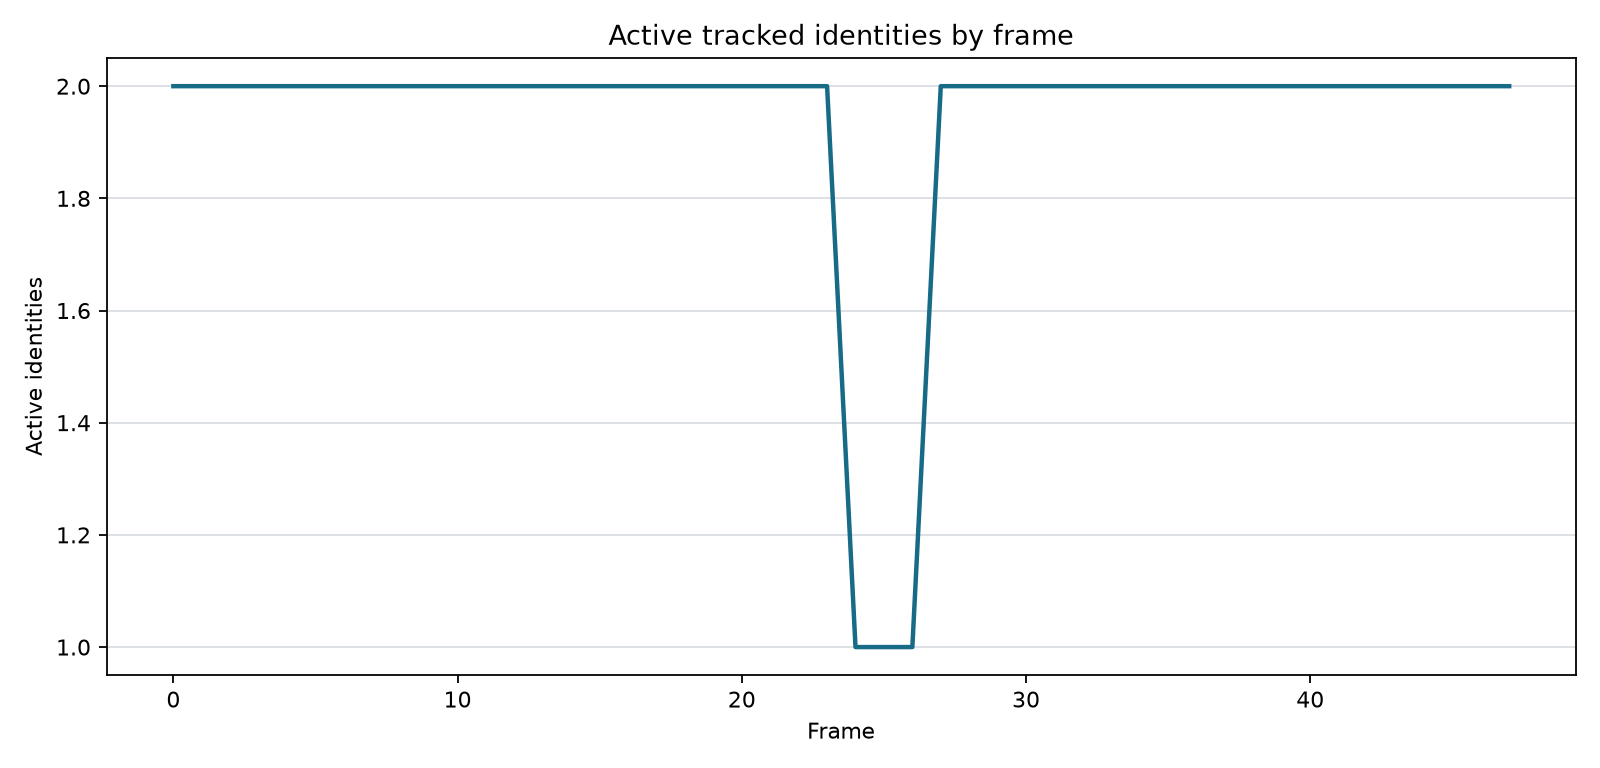

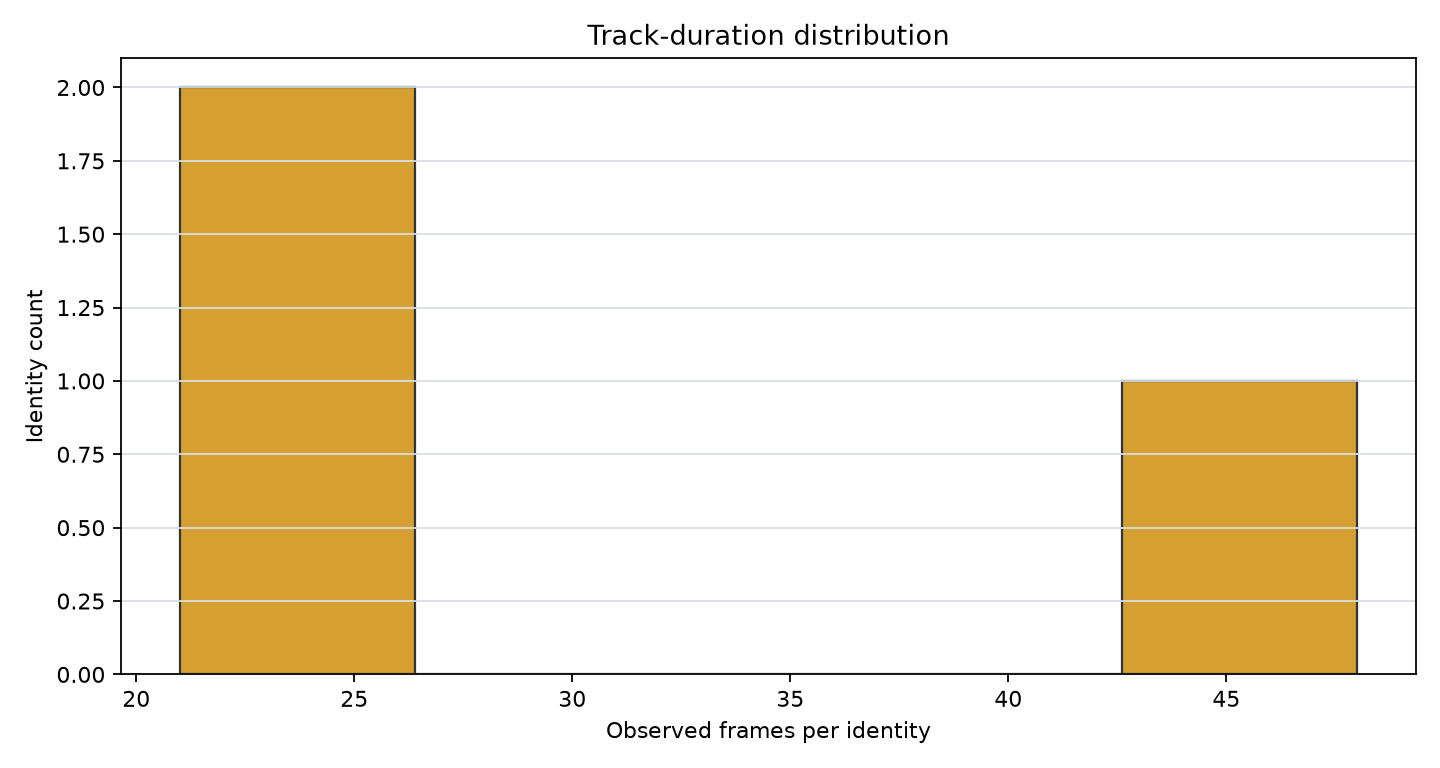

In [6]:
for plot_name in ["active_identities_over_time.png", "track_duration_distribution.png"]:
    plot_path = BASELINE_OUTPUT / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path)))

display(Video(str(BASELINE_OUTPUT / "annotated_baseline.mp4"), embed=True, width=720))

## Checks and interpretation

The detection-cache equality assertion proves that downstream experiments can consume the same detections. The plots describe tracker behavior; only the TrackEval table measures accuracy. Demo results validate execution, not football-domain performance.

Next: run `02_SceneCut_ReID_Recovery.ipynb`, which keeps this cache fixed and changes only cut handling and identity recovery.